# Main V7 — Preictal Window Sensitivity

## Motivation

V3–V6 use a **30-minute preictal window** (minus 5-min SPH = 25 min effective).
Some literature papers argue shorter windows (5–15 min) better capture the
preictal state and explain performance gaps. V7 tests whether preictal window
length drives the cross-patient LOPO results.

**Experimental design**: broadband GC features (same as V4, VAR(5) + 67 graph
descriptors) with PREICTAL_SEC ∈ {10, 15, 30} min. SPH fixed at 5 min throughout.
The 30-min result replicates V4 on the same feature set for a clean comparison.

**Key question**: Does a shorter preictal window improve cross-patient skill score?


In [1]:
# --- portable repo bootstrap (added for public release; locates the repo root) ---
import sys as _sys, pathlib as _pl
REPO = _pl.Path.cwd()
while not (REPO / 'src' / 'config.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
_sys.path.insert(0, str(REPO / 'src'))
from pathlib import Path
CODE_DIR = str(REPO); CODE = REPO; CODEV2 = REPO; PROJECT_DIR = REPO
# --------------------------------------------------------------------------------

# Cell 0 — Imports & config
import os, sys, json, warnings, time
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# [path set by bootstrap] CODE_DIR = r"<repo>/Code"
sys.path.insert(0, CODE_DIR)

from config import (
    DATA_ROOT, CANONICAL_CHANNELS, N_CHANNELS, FS,
    WINDOW_SEC, STEP_SEC, GC_ORDER,
    EXCLUDED_PATIENTS, RESULTS_DIR,
    INTERICTAL_MULTIPLIER, MAX_INTERICTAL_ABS, RANDOM_SEED,
    SPH_SEC,
)
from summary_parser import parse_all_summaries
from data_loader import load_edf
import preprocessing as _pp  # monkey-patched per setting

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

np.random.seed(RANDOM_SEED)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Preictal window settings to test (minutes).
# SPH stays fixed at 5 min → effective window = PREICTAL - 5.
PREICTAL_SETTINGS = [10, 15, 30]   # 30 min = V4 reference

V7_CACHE_DIR = os.path.join(CODE_DIR, 'cache_gc_features_v7')
os.makedirs(V7_CACHE_DIR, exist_ok=True)

print(f'SPH (fixed) : {SPH_SEC//60} min')
print(f'Preictal settings : {PREICTAL_SETTINGS} min')
print(f'Effective windows : {[p - SPH_SEC//60 for p in PREICTAL_SETTINGS]} min')
print(f'GC order : {GC_ORDER}  (broadband VAR(5))')
print(f'V7 cache : {V7_CACHE_DIR}')


SPH (fixed) : 5 min
Preictal settings : [10, 15, 30] min
Effective windows : [5, 10, 25] min
GC order : 5  (broadband VAR(5))
V7 cache : <repo>/Code/gc_v7_features


## 1 · Broadband GC + graph features

In [2]:
# Cell 1 — Broadband GC (VAR(5), A_total = Σ|A_k|) + 67-feature graph descriptor

def estimate_var_broadband(window, p=GC_ORDER, eps=1e-10):
    n_ch, T = window.shape
    X = window - window.mean(axis=1, keepdims=True)
    T_eff = T - p
    if T_eff < n_ch * p + 1:
        return np.zeros((n_ch, n_ch), dtype=np.float32), False
    Y = X[:, p:]
    Z = np.vstack([X[:, p - lag : p - lag + T_eff] for lag in range(1, p + 1)])
    ZZT = (Z @ Z.T) / T_eff + eps * np.eye(p * n_ch)
    YZT = (Y @ Z.T) / T_eff
    B   = YZT @ np.linalg.inv(ZZT)
    A_total = sum(np.abs(B[:, k * n_ch:(k + 1) * n_ch]) for k in range(p))
    return A_total.astype(np.float32), True


def extract_graph_features(A):
    frob = np.linalg.norm(A, 'fro')
    if frob > 1e-10:
        A = A / frob
    n    = A.shape[0]
    off  = ~np.eye(n, dtype=bool)
    a_off = A[off]
    in_deg   = A.sum(axis=1) - np.diag(A)
    out_deg  = A.sum(axis=0) - np.diag(A)
    net_flow = out_deg - in_deg
    mean_off = a_off.mean(); std_off  = a_off.std()
    max_off  = a_off.max();  min_off  = a_off.min()
    asym     = np.abs(A - A.T)
    asym_off = asym[np.triu_indices(n, k=1)]
    mean_asym = asym_off.mean(); std_asym = asym_off.std()
    thr      = 0.5 * max(float(max_off), 1e-12)
    density  = float((a_off > thr).mean())
    spec_rad = float(np.max(np.abs(np.linalg.eigvals(A))))
    sv = np.linalg.svd(A, compute_uv=False)
    sv5 = sv[:5] if len(sv) >= 5 else np.pad(sv, (0, 5 - len(sv)))
    return np.concatenate([in_deg, out_deg, net_flow,
        [mean_off, std_off, max_off, min_off, mean_asym, std_asym, density, spec_rad],
        sv5]).astype(np.float32)

FEATS_PER_WIN = 67
print('GC + graph-feature functions defined.')
print(f'Features per window : {FEATS_PER_WIN}')


GC + graph-feature functions defined.
Features per window : 67


## 2 · Compute / cache GC features per patient per preictal setting

In [3]:
# Cell 2 — Per-patient, per-setting feature extraction with preictal monkey-patch

def _cache_paths(preictal_min, pid):
    d = Path(V7_CACHE_DIR) / f'{preictal_min}min' / pid
    return d / 'features.npy', d / 'labels.npy'


def load_gc_features(pid, seizure_map, preictal_min, force=False):
    feat_p, lab_p = _cache_paths(preictal_min, pid)
    if not force and feat_p.exists() and lab_p.exists():
        X = np.load(str(feat_p)); y = np.load(str(lab_p))
        print(f'  [cache] {pid} ({preictal_min}min)  {X.shape}')
        return X, y

    feat_p.parent.mkdir(parents=True, exist_ok=True)

    # Override preictal window before preprocessing
    _pp.PREICTAL_SEC = preictal_min * 60

    pdir      = Path(DATA_ROOT) / pid
    all_feats, all_labs = [], []

    for fname, seizures in sorted(seizure_map.items()):
        edf_path = pdir / fname
        if not edf_path.exists():
            continue
        try:
            raw, fs = load_edf(str(edf_path))
        except Exception:
            continue
        windows, labels, _ = _pp.preprocess_file(raw, seizures, fs)
        if len(windows) == 0:
            continue
        file_feats = []
        for win in windows:
            A, ok = estimate_var_broadband(win)
            file_feats.append(extract_graph_features(A) if ok
                               else np.zeros(FEATS_PER_WIN, dtype=np.float32))
        F = np.stack(file_feats)
        valid = ~np.all(F == 0, axis=1)
        all_feats.append(F[valid]); all_labs.append(labels[valid])

    _pp.PREICTAL_SEC = 30 * 60  # restore default

    if not all_feats:
        return None, None
    X = np.concatenate(all_feats).astype(np.float32)
    y = np.concatenate(all_labs).astype(np.int8)
    np.save(str(feat_p), X); np.save(str(lab_p), y)
    print(f'  [computed] {pid} ({preictal_min}min)  {X.shape}')
    return X, y


all_seizures  = parse_all_summaries(DATA_ROOT)
patients_all  = sorted([
    p for p in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, p))
    and p.startswith('chb') and p not in EXCLUDED_PATIENTS
])

gc_raw = {}   # {preictal_min: {pid: (X, y)}}
for pm in PREICTAL_SETTINGS:
    print(f'\n=== Preictal {pm} min ===')
    gc_raw[pm] = {}
    t0 = time.time()
    for pid in patients_all:
        if pid not in all_seizures:
            continue
        X, y = load_gc_features(pid, all_seizures[pid], pm)
        if X is None or (y == 1).sum() == 0:
            print(f'  skip {pid}: no preictal windows')
            continue
        gc_raw[pm][pid] = (X, y)
    print(f'  {len(gc_raw[pm])} patients  |  {(time.time()-t0)/60:.1f} min')


[INFO] chb01: 7 seizure-containing files, 7 total seizures
[INFO] chb02: 3 seizure-containing files, 3 total seizures
[INFO] chb03: 7 seizure-containing files, 7 total seizures
[INFO] chb04: 3 seizure-containing files, 4 total seizures
[INFO] chb05: 5 seizure-containing files, 5 total seizures
[INFO] chb06: 7 seizure-containing files, 10 total seizures
[INFO] chb07: 3 seizure-containing files, 3 total seizures
[INFO] chb08: 5 seizure-containing files, 5 total seizures
[INFO] chb09: 3 seizure-containing files, 4 total seizures
[INFO] chb10: 7 seizure-containing files, 7 total seizures
[INFO] chb11: 3 seizure-containing files, 3 total seizures
[INFO] chb12: 13 seizure-containing files, 40 total seizures
[INFO] chb13: 8 seizure-containing files, 12 total seizures
[INFO] chb14: 7 seizure-containing files, 8 total seizures
[INFO] chb15: 14 seizure-containing files, 20 total seizures
[INFO] chb16: 6 seizure-containing files, 10 total seizures
[INFO] chb17: 3 seizure-containing files, 3 total

## 3 · Interictal cap + LOPO pipeline

In [4]:
# Cell 3 — Apply interictal cap (same as V4/V6)

gc_data = {}
for pm in PREICTAL_SETTINGS:
    gc_data[pm] = {}
    for pid, (X, y) in gc_raw[pm].items():
        n_pre = int((y == 1).sum())
        cap   = min(int((y == 0).sum()), INTERICTAL_MULTIPLIER * n_pre, MAX_INTERICTAL_ABS)
        if int((y == 0).sum()) > cap:
            rng  = np.random.default_rng(RANDOM_SEED + hash(pid) % 10_000)
            keep = np.sort(np.concatenate([
                np.where(y == 1)[0],
                rng.choice(np.where(y == 0)[0], size=cap, replace=False)
            ]))
            X, y = X[keep], y[keep]
        gc_data[pm][pid] = (X, y)
    tot_pre = sum(int((yy == 1).sum()) for _, (_, yy) in gc_data[pm].items())
    tot_int = sum(int((yy == 0).sum()) for _, (_, yy) in gc_data[pm].items())
    print(f'{pm:2d}min: {len(gc_data[pm])} patients  pre={tot_pre:,}  int={tot_int:,}')


10min: 21 patients  pre=3,029  int=15,125
15min: 21 patients  pre=5,667  int=22,926
30min: 21 patients  pre=10,908  int=26,790


In [5]:
# Cell 4 — LOPO machinery (LR only — fast, sufficient for sensitivity test)

METRIC_KEYS = ['auc','auc_pr','sensitivity','specificity',
               'precision','f1','balanced_accuracy','fpr_per_hour']


from seizure_metrics import generate_alarms, false_alarms_per_hour
from config import ALARM_K, ALARM_M, ALARM_REFRACTORY, STEP_SEC

def evaluate_fold(probs, y_te, n_int_hours):
    if len(np.unique(y_te)) < 2:
        return None
    auc    = roc_auc_score(y_te, probs)
    auc_pr = average_precision_score(y_te, probs)
    fpr, tpr, thr = roc_curve(y_te, probs)
    t      = float(thr[np.argmax(tpr - fpr)])
    pred   = (probs >= t).astype(int)
    tp = int(((pred==1)&(y_te==1)).sum()); fp = int(((pred==1)&(y_te==0)).sum())
    tn = int(((pred==0)&(y_te==0)).sum()); fn = int(((pred==0)&(y_te==1)).sum())
    sens = tp/max(tp+fn,1); spec = tn/max(tn+fp,1); prec = tp/max(tp+fp,1)
    return dict(auc=auc, auc_pr=auc_pr, sensitivity=sens, specificity=spec,
                precision=prec, f1=2*prec*sens/max(prec+sens,1e-9),
                balanced_accuracy=0.5*(sens+spec),
                fpr_per_hour=false_alarms_per_hour(generate_alarms(pred.astype(float), 0.5, ALARM_K, ALARM_M, ALARM_REFRACTORY), y_te, STEP_SEC))


def run_lopo_lr(feat_data, pids, label=''):
    pipe = Pipeline([('scl', StandardScaler()),
                     ('clf', LogisticRegression(max_iter=400, solver='lbfgs',
                         class_weight='balanced', random_state=RANDOM_SEED))])
    grid = {'clf__C': [0.01, 0.1, 1.0, 10.0]}
    rows = []; t0 = time.time()
    print(f'\n══ LR LOPO [{label}] — {len(pids)} folds ══')
    for i, test_pid in enumerate(pids, 1):
        Xtr = np.concatenate([feat_data[p][0] for p in pids if p != test_pid])
        ytr = np.concatenate([feat_data[p][1] for p in pids if p != test_pid])
        grp = np.concatenate([np.full(len(feat_data[p][1]), j)
                               for j, p in enumerate(pids) if p != test_pid])
        Xte, yte = feat_data[test_pid]
        cv = GroupKFold(n_splits=min(3, len(np.unique(grp))))
        gs = GridSearchCV(pipe, grid, cv=cv, scoring='average_precision',
                          n_jobs=-1, refit=True, verbose=0)
        gs.fit(Xtr, ytr, groups=grp)
        probs = gs.best_estimator_.predict_proba(Xte)[:, 1]
        m = evaluate_fold(probs, yte, (yte==0).sum() * STEP_SEC / 3600.)
        if m:
            m['patient'] = test_pid; rows.append(m)
            print(f'  [{i:2d}] {test_pid}  AUC={m["auc"]:.3f}  PR={m["auc_pr"]:.3f}')
    print(f'  done in {(time.time()-t0)/60:.1f} min')
    return pd.DataFrame(rows)

print('LOPO machinery ready.')


LOPO machinery ready.


## 4 · Run LOPO for all preictal settings

In [6]:
# Cell 5 — Run LR LOPO for each preictal setting

lopo_v7 = {}

for pm in PREICTAL_SETTINGS:
    pids = sorted(gc_data[pm].keys())
    df   = run_lopo_lr(gc_data[pm], pids, label=f'{pm}min')
    lopo_v7[pm] = df

    # Save CSV with MEAN/STD rows
    df_out  = df.copy()
    mean_row = {'patient': 'MEAN', **{k: round(df[k].mean(), 4) for k in METRIC_KEYS}}
    std_row  = {'patient': 'STD',  **{k: round(df[k].std(),  4) for k in METRIC_KEYS}}
    df_out   = pd.concat([df_out, pd.DataFrame([mean_row, std_row])], ignore_index=True)
    path     = os.path.join(RESULTS_DIR, f'lopo_v7_LR_{pm}min.csv')
    df_out.to_csv(path, index=False)
    print(f'Saved {path}')



══ LR LOPO in] — 21 folds ══
  [ 1] chb01  AUC=0.415  PR=0.135
  [ 2] chb02  AUC=0.423  PR=0.194
  [ 3] chb03  AUC=0.466  PR=0.166
  [ 4] chb04  AUC=0.435  PR=0.153
  [ 5] chb05  AUC=0.559  PR=0.203
  [ 6] chb06  AUC=0.554  PR=0.199
  [ 7] chb07  AUC=0.521  PR=0.163
  [ 8] chb08  AUC=0.607  PR=0.217
  [ 9] chb09  AUC=0.551  PR=0.180
  [10] chb10  AUC=0.644  PR=0.252
  [11] chb13  AUC=0.468  PR=0.151
  [12] chb14  AUC=0.462  PR=0.157
  [13] chb15  AUC=0.507  PR=0.169
  [14] chb16  AUC=0.492  PR=0.173
  [15] chb17  AUC=0.618  PR=0.244
  [16] chb18  AUC=0.497  PR=0.158
  [17] chb19  AUC=0.396  PR=0.135
  [18] chb20  AUC=0.446  PR=0.158
  [19] chb22  AUC=0.348  PR=0.126
  [20] chb23  AUC=0.466  PR=0.163
  [21] chb24  AUC=0.470  PR=0.158
  done in 0.2 min
Saved results/lopo_v7_LR_10min.csv

══ LR LOPO in] — 21 folds ══
  [ 1] chb01  AUC=0.472  PR=0.238
  [ 2] chb02  AUC=0.537  PR=0.267
  [ 3] chb03  AUC=0.442  PR=0.152
  [ 4] chb04  AUC=0.421  PR=0.170
  [ 5] chb05  AUC=0.587  PR=0.279
  [

## 5 · Results — Sensitivity analysis + Skill Score

In [7]:
# Cell 6 — Comparison table with prevalence-adjusted Skill Score

def skill_scores(df, feat_data):
    prev = {pid: float((y==1).sum())/len(y) for pid,(_, y) in feat_data.items()}
    vals = [(row['auc_pr'] - prev[row['patient']]) / max(1 - prev[row['patient']], 1e-9)
            for _, row in df.iterrows() if row['patient'] in prev]
    return float(np.mean(vals)), float(np.std(vals)), float(np.mean(list(prev.values())))


summary_rows = []
for pm, df in lopo_v7.items():
    sk_mean, sk_std, mean_prev = skill_scores(df, gc_data[pm])
    summary_rows.append({
        'preictal_min':   pm,
        'eff_window_min': pm - SPH_SEC // 60,
        'n_patients':     len(df),
        'mean_prev':      round(mean_prev, 4),
        'auc':            round(df['auc'].mean(), 4),
        'auc_pr':         round(df['auc_pr'].mean(), 4),
        'skill':          round(sk_mean, 4),
        'skill_std':      round(sk_std, 4),
        'sensitivity':    round(df['sensitivity'].mean(), 4),
        'fpr_per_hour':   round(df['fpr_per_hour'].mean(), 1),
    })

summ = pd.DataFrame(summary_rows)
summ.to_csv(os.path.join(RESULTS_DIR, 'lopo_v7_summary.csv'), index=False)

print('══ V7 — Preictal window sensitivity (LR LOPO, broadband GC) ══')
print(f'{"Preictal":>10}  {"Eff.win":>8}  {"Prev":>6}  {"AUC":>7}  '
      f'{"AUC-PR":>7}  {"Skill":>7}  {"±":>6}')
print('─' * 68)
for _, r in summ.iterrows():
    marker = ' ← current (V4)' if r['preictal_min'] == 30 else ''
    print(f'{r["preictal_min"]:>8}min  {r["eff_window_min"]:>6}min  '
          f'{r["mean_prev"]:>6.3f}  {r["auc"]:>7.4f}  {r["auc_pr"]:>7.4f}  '
          f'{r["skill"]:>7.4f}  ±{r["skill_std"]:>5.4f}{marker}')

print('\nSaved results/lopo_v7_summary.csv')


══ V7 — Preictal window sensitivity (LR LOPO, broadband GC) ══
  Preictal   Eff.win    Prev      AUC   AUC-PR    Skill       ±
────────────────────────────────────────────────────────────────────
    10.0min     5.0min   0.167   0.4927   0.1740   0.0086  ±0.0393
    15.0min    10.0min   0.202   0.4916   0.2072   0.0067  ±0.0431
    30.0min    25.0min   0.344   0.4919   0.3597   0.0219  ±0.0939 ← current (V4)

Saved results/lopo_v7_summary.csv


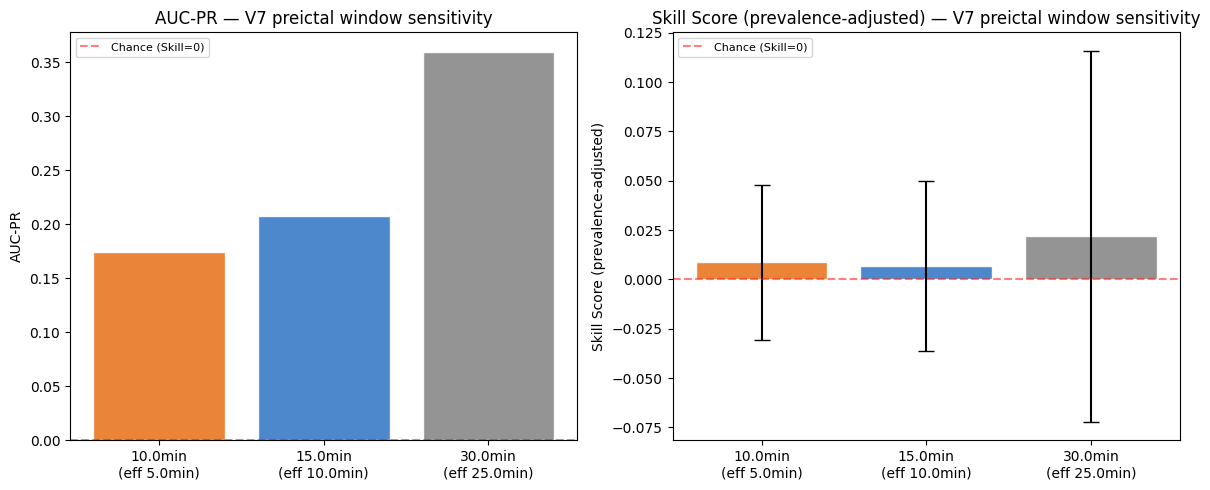

Saved results/v7_preictal_sensitivity.png


In [8]:
# Cell 7 — Visualisation: Skill Score and AUC-PR across preictal settings

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = [f'{r["preictal_min"]}min\n(eff {r["eff_window_min"]}min)' for _, r in summ.iterrows()]

for ax, metric, ylabel in zip(axes,
                               ['auc_pr', 'skill'],
                               ['AUC-PR', 'Skill Score (prevalence-adjusted)']):
    vals = summ[metric].values
    errs = summ['skill_std'].values if metric == 'skill' else None
    bars = ax.bar(labels, vals, yerr=errs, capsize=6,
                  color=['#e87722' if m == 10 else '#3a7bc8' if m == 15 else '#888'
                         for m in summ['preictal_min']],
                  edgecolor='white', alpha=0.9)
    ax.axhline(0, color='red', linestyle='--', alpha=0.5, label='Chance (Skill=0)')
    ax.set_title(f'{ylabel} — V7 preictal window sensitivity')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v7_preictal_sensitivity.png'), dpi=130)
plt.show()
print('Saved results/v7_preictal_sensitivity.png')
